### Instala las librerias sino las tiene :)

In [32]:
#pip install pandas numpy matplotlib seaborn scikit-learn openpyxl jupyter

### 1. Importar librerías

In [ ]:
#Esto lo pongo solo para informativo
import sys

#Instalamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")


### 2. Cargar dataset

In [6]:
df = pd.read_excel("../data/online_retail.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### 3. Análisis Exploratorio de Datos (EDA)

In [7]:
# Mostrar información general del dataset
# Permite visualizar el número de registros, tipos de datos y valores no nulos
df.info()

# Mostrar estadísticas descriptivas de las variables numéricas
# Incluye media, desviación estándar, valores mínimos y máximos
df.describe()

# Verificar la cantidad de valores nulos por columna
# Es importante identificar si existen datos faltantes que deban limpiarse
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

### 4. Limpieza y Preprocesamiento de Datos

#### 4.1 Eliminación de registros sin identificación de cliente

In [8]:
# Eliminar registros sin Customer ID
df = df.dropna(subset=["Customer ID"])

# Verificar nueva dimensión del dataset
df.shape

(417534, 8)

#### 4.2 Eliminación de devoluciones

In [9]:
# Eliminar facturas que comienzan con "C"
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Verificar dimensión nuevamente
df.shape

(407695, 8)

#### 4.3 Crear variable TotalPrice

In [10]:
# Crear variable de valor total
df["TotalPrice"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


#### 4.4 Verificación final después de limpieza

In [11]:
df.describe()
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

### 5. Construcción del Modelo RFM

#### 5.1 Definición de la fecha de referencia

In [12]:
# Definir fecha de referencia
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2010-12-10 20:01:00')

#### 5.2 Construcción de la tabla RFM

In [13]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

# Renombrar columnas
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


#### 5.3 Verificación de la matriz RFM

In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,4314.000000,4314.000000,4314.000000
mean,91.269124,4.454103,2047.288659
std,96.943482,8.168658,8912.523243
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.950000
50%,53.000000,2.000000,705.550000
75%,136.000000,5.000000,1722.802500
max,374.000000,205.000000,349164.350000


### 6. Escalamiento de Variables

#### 6.1 Justificación

Las variables Recency, Frequency y Monetary tienen escalas muy diferentes:

Recency está en días.

Frequency es número de compras.

Monetary puede llegar a cientos de miles.

Si no escalamos, el modelo dará más peso a Monetary y el clustering será incorrecto.

#### 6.2 Aplicar StandardScaler

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

#### 6.3 Convertir a DataFrame

In [16]:
rfm_scaled = pd.DataFrame(rfm_scaled, 
                          columns=["Recency", "Frequency", "Monetary"],
                          index=rfm.index)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.760643,0.801436,-0.187895
12347.0,-0.910627,-0.300464,-0.081240
12348.0,-0.178157,-0.422897,-0.204806
12349.0,-0.497968,-0.178031,0.070005
12351.0,-0.828095,-0.422897,-0.195967


#### 6.4 Verificación

In [17]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.314000e+03,4.314000e+03,4.314000e+03
mean,8.647078e-18,4.282362e-17,1.647062e-18
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-9.312600e-01,-4.228973e-01,-2.297358e-01
25%,-7.558798e-01,-4.228973e-01,-1.951793e-01
50%,-3.948028e-01,-3.004640e-01,-1.505628e-01
75%,4.614654e-01,6.683599e-02,-3.641211e-02
max,2.916789e+00,2.455350e+01,3.895163e+01


### 7. Aplicación de K-Means

#### 7.1 Método del Codo

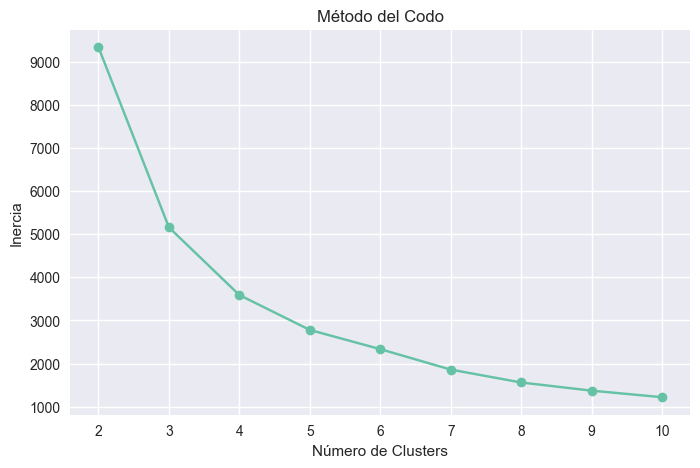

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")

plt.savefig("../visualizations/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()



#### 7.2 Aplicar K-Means con k óptimo y Ver tamaño de cada cluster

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

rfm["Cluster"].value_counts()


Cluster
0    3207
1    1049
3      53
2       5
Name: count, dtype: int64

#### 7.4 Perfil promedio por cluster 

In [20]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,42.996882,4.469598,1743.129790
1,243.086749,1.658723,595.746486
2,5.600000,113.600000,215543.670000
3,15.433962,48.547170,29040.181566


### 8. Validación del número óptimo de clusters (Silhouette Score)

In [21]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm["Cluster"])
score

0.6099729618321483

### 9. Aplicación de DBSCAN

In [22]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
rfm["Cluster_DBSCAN"] = dbscan.fit_predict(rfm_scaled)

rfm["Cluster_DBSCAN"].value_counts()

Cluster_DBSCAN
 0    4277
-1      37
Name: count, dtype: int64

### 10. Reducción de dimensionalidad (PCA)

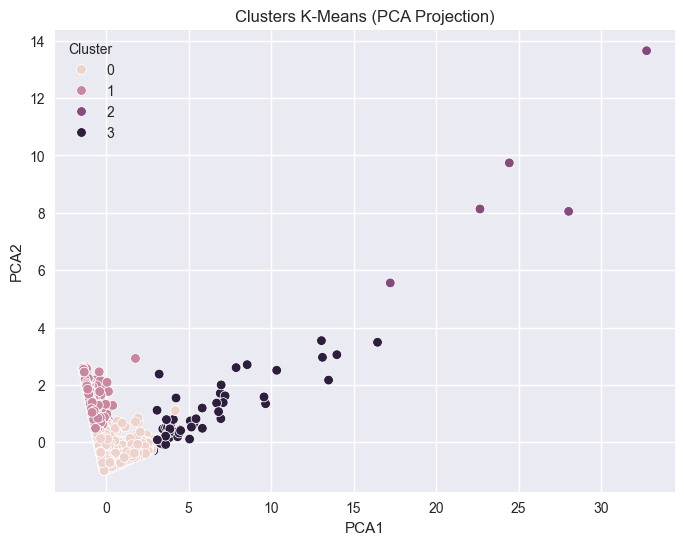

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:,0]
rfm["PCA2"] = rfm_pca[:,1]

#Visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster")
plt.title("Clusters K-Means (PCA Projection)")
plt.show()


### 11. t-SNE (detección no lineal)

In [24]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
rfm_tsne = tsne.fit_transform(rfm_scaled)

rfm["TSNE1"] = rfm_tsne[:,0]
rfm["TSNE2"] = rfm_tsne[:,1]

### 12. Comparación entre Modelos de Clustering

Se aplicaron dos algoritmos de aprendizaje no supervisado: K-Means y DBSCAN, con el objetivo de segmentar clientes a partir de variables RFM (Recency, Frequency y Monetary).

---

#### K-Means

El modelo K-Means identificó 4 clusters claramente diferenciados:

- Un grupo grande de clientes activos de valor medio.
- Un grupo de clientes inactivos o de bajo valor.
- Un grupo pequeño de clientes premium.
- Un grupo extremadamente pequeño de clientes VIP con gasto y frecuencia muy elevados.

Ventajas observadas:
- Segmentación clara y fácilmente interpretable.
- Permite caracterizar perfiles de clientes con métricas promedio.
- Adecuado cuando se desea dividir el mercado en segmentos bien definidos.

Limitaciones:
- Sensible a outliers (detectó clusters muy pequeños debido a clientes con gasto extremadamente alto).
- Requiere definir previamente el número de clusters.

---

#### DBSCAN

DBSCAN no requiere definir el número de clusters previamente y es capaz de detectar puntos considerados ruido.

Ventajas observadas:
- Detecta outliers de manera explícita.
- Puede identificar estructuras de datos no esféricas.
- Más robusto frente a valores extremos.

Limitaciones:
- Sensible a la elección de parámetros (eps y min_samples).
- Puede generar un único cluster dominante si la densidad de datos no está claramente separada.
- Menos interpretable para segmentación comercial tradicional.

---

#### Comparación Técnica

- K-Means generó segmentos más interpretables desde el punto de vista de negocio.
- DBSCAN mostró mayor capacidad para identificar clientes extremadamente atípicos como ruido.
- La estructura de los datos RFM parece ajustarse mejor a un modelo basado en centroides como K-Means.
- La presencia de clusters muy pequeños en K-Means indica alta dispersión en la variable Monetary.

---

#### Modelo Recomendado

Para fines de segmentación comercial y estrategias de marketing, K-Means resulta más adecuado debido a su interpretabilidad y facilidad para caracterizar perfiles de clientes.

DBSCAN puede utilizarse como complemento para detección de clientes atípicos o análisis de anomalías.

---

#### Conclusión General

Ambos modelos aportan valor desde perspectivas distintas.  
K-Means es más útil para segmentación estratégica de clientes, mientras que DBSCAN es más apropiado para detección de comportamientos extremos o análisis de anomalías.

La elección final del modelo depende del objetivo del negocio: segmentación estructurada o identificación de outliers.


### Visualización de Clusters K-Means

#### PCA

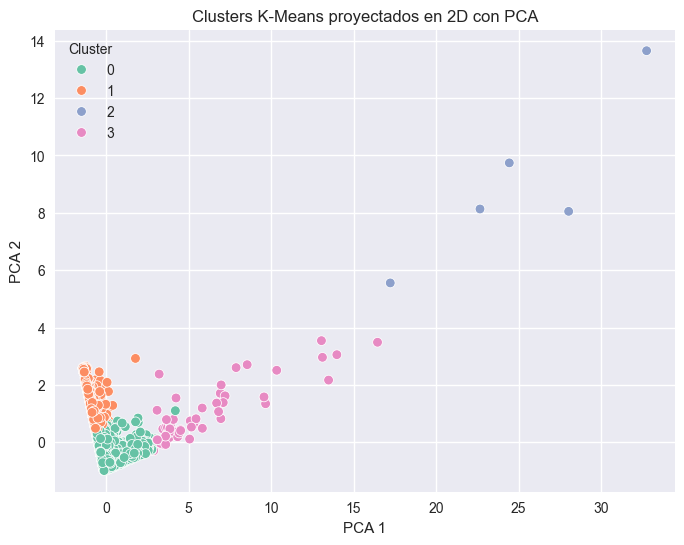

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Agregar al dataframe
rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

# Graficar
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster", palette="Set2")
plt.title("Clusters K-Means proyectados en 2D con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Guardar imagen
plt.savefig("../visualizations/pca_clusters.png", dpi=300, bbox_inches="tight")

plt.show()



####  t-SNE

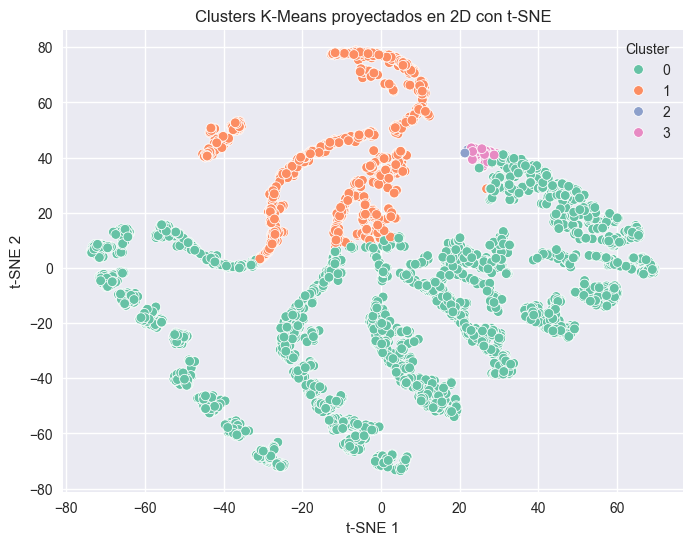

In [26]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
rfm_tsne = tsne.fit_transform(rfm_scaled)

rfm["TSNE1"] = rfm_tsne[:, 0]
rfm["TSNE2"] = rfm_tsne[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="TSNE1", y="TSNE2", hue="Cluster", palette="Set2")
plt.title("Clusters K-Means proyectados en 2D con t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

# Guardar imagen
plt.savefig("../visualizations/tsne_clusters.png", dpi=300, bbox_inches="tight")

plt.show()



### Visualización de Clusters DBSCAN

#### PCA

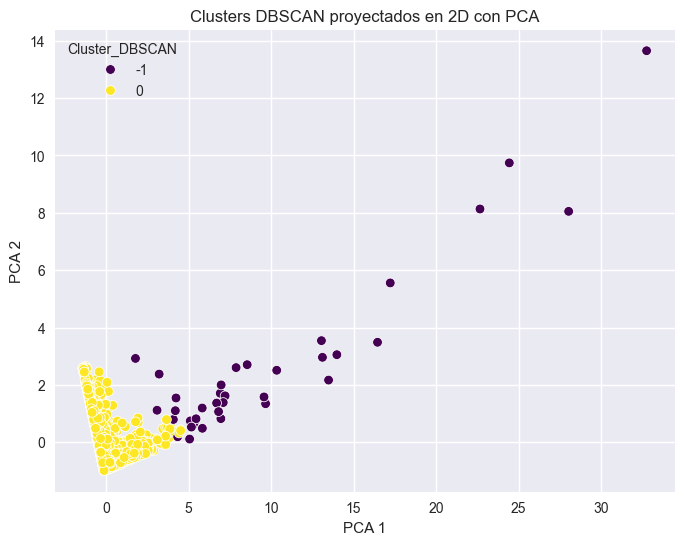

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster_DBSCAN", palette="viridis")
plt.title("Clusters DBSCAN proyectados en 2D con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Guardar imagen
plt.savefig("../visualizations/pca_clusters_dbscan.png", dpi=300, bbox_inches="tight")

plt.show()

#### t-SNE

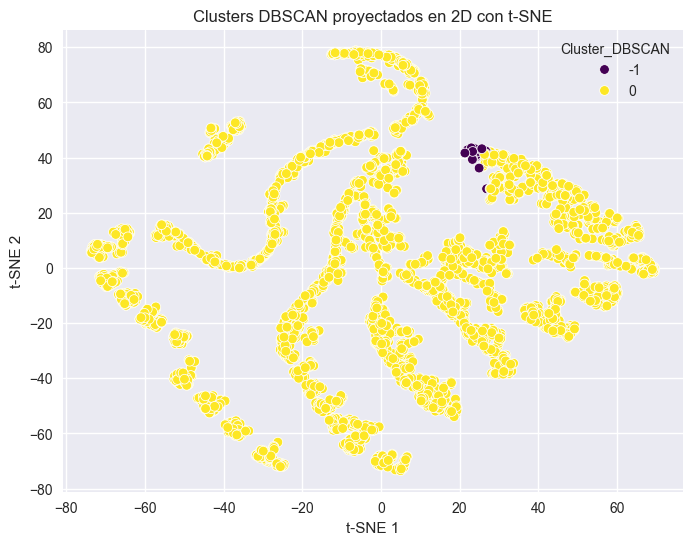

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="TSNE1", y="TSNE2", hue="Cluster_DBSCAN", palette="viridis")
plt.title("Clusters DBSCAN proyectados en 2D con t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

# Guardar imagen
plt.savefig("../visualizations/tsne_clusters_dbscan.png", dpi=300, bbox_inches="tight")

plt.show()

### Tabla Resumen de Características Medias por Cluster

In [29]:
display(rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean())

,Recency,Frequency,Monetary
Cluster,,,
0,42.996882,4.469598,1743.129790
1,243.086749,1.658723,595.746486
2,5.600000,113.600000,215543.670000
3,15.433962,48.547170,29040.181566


###  Reflexión y comunicación

#### ¿Qué tipo de perfiles se pueden identificar?

A partir de los resultados del agrupamiento K-Means, se pueden identificar los siguientes perfiles de clientes, caracterizados por sus valores promedio en Recencia (días desde la última compra), Frecuencia (número de compras) y Monetario (gasto total):

#### Cluster 0: Clientes Activos/Estándar
*   **Recencia:**  43 días (compraron hace relativamente poco).
*   **Frecuencia:**  4.5 compras (frecuencia moderada).
*   **Monetario:**  $1743 (gasto moderado).
*   **Descripción:** Este es el grupo más grande de clientes. Son compradores regulares que realizan transacciones con una frecuencia y gasto estándar. Representan la base de clientes principal de la empresa.

#### Cluster 1: Clientes Inactivos/En Riesgo
*   **Recencia:**  243 días (no han comprado en mucho tiempo).
*   **Frecuencia:**  1.6 compras (muy baja frecuencia).
*   **Monetario:**  $595 (bajo gasto total).
*   **Descripción:** Este segmento incluye clientes que han estado inactivos por un período prolongado. Son clientes con alto riesgo de abandono o que ya han abandonado. Requieren estrategias de reactivación.

#### Cluster 2: Clientes VIP/Alto Valor (Muy Exclusivos)
*   **Recencia:**  5.6 días (compraron muy recientemente).
*   **Frecuencia:**  113.6 compras (frecuencia extremadamente alta).
*   **Monetario:**  $215,543 (gasto excepcionalmente alto).
*   **Descripción:** Un grupo muy pequeño pero extremadamente valioso. Son los clientes más leales, frecuentes y que más gastan. Son cruciales para el negocio y podrían ser tratados como clientes "Key Accounts" o "Whales".

#### Cluster 3: Clientes Leales/Premium
*   **Recencia:**  15.4 días (compraron recientemente).
*   **Frecuencia:**  48.5 compras (frecuencia alta).
*   **Monetario:**  $29,040 (gasto alto).
*   **Descripción:** Estos son clientes muy valiosos y fieles, que compran con alta frecuencia y gastan significativamente. Son un segmento objetivo para programas de lealtad y ofertas exclusivas.

### Resumen de Perfiles:

*   **Cluster 0 (Mayoría):** Clientes promedio, base del negocio.
*   **Cluster 1 (Considerable):** Clientes en riesgo de abandono o ya inactivos.
*   **Cluster 2 (Mínimo):** Clientes de valor excepcional (VIP).
*   **Cluster 3 (Pequeño):** Clientes de alto valor y lealtad.

#### ¿Qué diferencias clave surgieron entre los modelos?

* K-Means: Generó segmentos de clientes más interpretables y fáciles de caracterizar para fines comerciales. Sin embargo, es sensible a los outliers y requiere que definamos el número de clusters previamente.

* DBSCAN: Fue más efectivo para identificar clientes extremadamente atípicos (considerados ruido) y no necesita una predefinición del número de clusters. No obstante, es sensible a la elección de sus parámetros y los resultados pueden ser menos interpretables comercialmente si la densidad de datos no está claramente separada.

Para propósitos de segmentación comercial, K-Means resultó ser más adecuado debido a su interpretabilidad, mientras que DBSCAN es mejor para la detección de anomalías.

#### ¿Qué limitaciones encontraron y cómo las abordarían?

1. **Con K-Means:**

    * Sensibilidad a Outliers: El modelo K-Means es sensible a los valores atípicos, lo que resultó en la creación de clusters muy pequeños (como el Cluster 2) para clientes con un gasto extremadamente alto. Esto puede distorsionar los centroides de los clusters y afectar la calidad de la segmentación general.

    > * Cómo abordaríamos: Se podrían aplicar técnicas de detección y tratamiento de outliers antes del clustering, como la Winsorización o la eliminación de los valores extremos si se considera ruido real, o utilizar algoritmos de clustering más robustos a outliers si la detección de estos es una prioridad.

    * Necesidad de definir 'k': Tuvimos que determinar el número óptimo de clusters (k) previamente, utilizando el método del codo y el coeficiente de Silhouette. Esto añade un paso manual y, en ocasiones, la elección puede no ser totalmente clara.
    > * Cómo abordaríamos: Se podrían explorar métodos más avanzados para la selección automática de 'k' o integrar la validación de 'k' dentro de un proceso iterativo que pruebe diferentes valores y evalúe la interpretabilidad de los resultados.

2. **Con DBSCAN:**

    * Sensibilidad a los Parámetros (eps y min_samples): Los resultados de DBSCAN son altamente dependientes de la correcta elección de eps (radio de vecindad) y min_samples (número mínimo de puntos). Una selección incorrecta puede llevar a un único cluster grande o a muchos puntos clasificados como ruido.
    > * Cómo abordaríamos: Se podría realizar una búsqueda sistemática de hiperparámetros (por ejemplo, utilizando un enfoque de cuadrícula o aleatorio) o utilizar herramientas visuales como el gráfico de k-distancia para ayudar a seleccionar eps de manera más informada. El ajuste fino de estos parámetros es crucial.
    * Menor Interpretabilidad Comercial: Aunque DBSCAN es bueno para identificar la densidad, los clusters generados pueden ser menos interpretables desde una perspectiva de negocio tradicional si no forman grupos esféricos o bien separados. Como se vio, generó un gran cluster y muchos puntos como ruido, lo cual es útil para outliers pero menos para segmentación de marketing.
    > * Cómo abordaríamos: Para fines de marketing, donde la interpretabilidad es clave, K-Means sigue siendo preferible. DBSCAN podría usarse como una herramienta complementaria para la detección de anomalías o para pre-procesar los datos eliminando el ruido antes de aplicar otros algoritmos de clustering más interpretables.